# Kantendetektion
In dieser Übung wird der Sobel-Operator zur Kantendetektion implementiert.
1. Lesen Sie das Kapitel 7 (Kanten und Konturen) aus dem Buch ”Digitale

2. Beantworten Sie folgende Fragen:

a) Was ist eine Kante und wie ist sie im Bild, in dessen Ableitung und dessen zweiten
Ableitung erkennbar?

- kante ist ein ort im bild wo sich die intensität auf kleinem raum entlang einer richtung stark verändert
- je stärker die intensitätsänderung desto deutlicher ist die kante

im bild:
- sichtbarer helligkeitssprung hell->dunkel oder dunkel->hell
- 1. ableitung: zeigt positiven ausschlag, wo die intensität ansteigt und einen negativen ausschlag wo sie abfällt, also eine klare spitze an der kantenpostition
- 2. ableitung: zeigt die kante als nulldurchgang (zero crossing), nulldurchgang markiert genau die kantenposition und erlaubt somit eine präzisere lokalisierung der kante

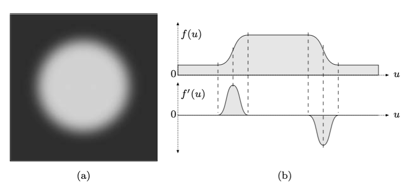
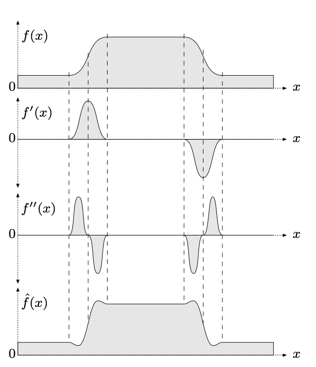

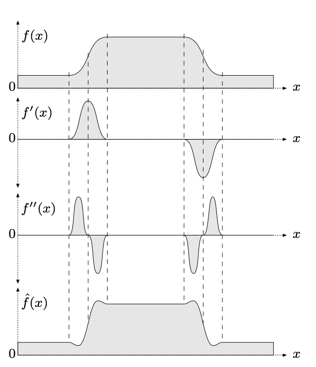

b) Was sind die partiellen Ableitungen eines Bildes? Was sagen sie aus?
- ein bild ist eine 2 dimensionale funktion -> also I(u,v) wobei u = horizontal und v = vertikal
- => deshalb gibt es 2 partielle ableitungen

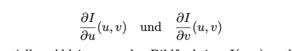

- bei einer misst man die intensitätsveränderung in horizontaler richtung -> reagiert also stark auf vertikal kanten
- bei der anderen misst man die intensitätsveränderung in vertikaler richtung -> reagiert also stark auf horizontale kanten

=> bei flachen bildregionen sind beide ableitungen annähern null

c) Was ist der Gradientenvektor (kurz: Gradient) eines Bildes? Was kann aus diesem abgelesen werden?
- der gradientvektor fasst beide partiellen ableitungen zu einem vektor zusammen
- **betrag des gradienten** -> wie stark ändert sich die intensität an der stelle
- **vektor** -> zeigt senkrecht zur kante die richtung des stärksten intensitätsanstiegs

**z.B.: vertikale kante**

dunkel | hell

vektor zeigt senkrecht zur kante von links nach rechts

d) Wie kann die Kantenstärke berechnet werden?
- die kantenstärke E(u,v) wird als der betrag vom gradienten berechnet

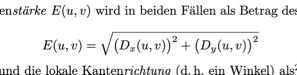

- Dx und Dy sind die filterergebnisse vom gradientenfilter (sobel, prewitt)
- rotationsinvariant (isotropisch) -> also unabhängig der orientierung der kante

**Vertikale Kante:**

50  50  200  200

50  50  200  200

→ Dx = 150, Dy = 0

→ E = √(150² + 0²) = 150

**Horizontale Kante:**

50   50   50   50

200  200  200  200

→ Dx = 0, Dy = 150

→ E = √(0² + 150²) = 150

**Diagonale Kante:**

→ Dx = 106, Dy = 106

→ E = √(106² + 106²) ≈ 150

e) Wie kann die lokale Kantenrichtung berechnet werden?

- lokale kantenrichtung kann durch den arctan von den beiden gradienten komponenten berechnet werden
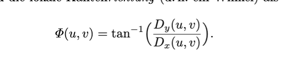
- => der gradient zeigt senkrecht zur kante also muss man den gradienten um 90 grad drehen

3. Implementieren Sie den Sobel-Operator.


b) Schreiben Sie hierzu eine Funktion, die die erste Ableitung in horizontaler Richtung
zurückgibt.

c) Und eine Funktion, die die erste Ableitung in vertikaler Richtung zurückgibt.

d) Zusätzlich soll eine Funktion implementiert werden, die die Kantenstärke durch den
Betrag des Gradienten berechnet.

In [21]:
import skimage as sk
import numpy as np
import matplotlib.pyplot as plt
from pygments.formatters import img

In [22]:
def rgb2gray(rgb):

    r, g, b = rgb[:,:,0], rgb[:,:,1], rgb[:,:,2]
    gray = 0.2989 * r + 0.5870 * g + 0.1140 * b

    return gray

In [23]:
image_1 = sk.io.imread("fhorn.jpg")
image_2 = rgb2gray(sk.io.imread("lena.jpg"))

img_dot_01 = rgb2gray(sk.io.imread('dot01.png'))
img_dot_02 = rgb2gray(sk.io.imread('dot02.png'))

a) Verwenden Sie Filter in der separablen Form. Das Filterergebnis soll skaliert sein
und wählen Sie eine geeignete Randbehandlung.

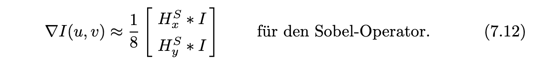

In [24]:
sobel_x = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1],
])/8

sobel_y = np.array([
    [-1, -2, -1],
    [0, 0, 0],
    [1, 2, 1]
])/8

funktion aus a3 für randbehandlung

In [25]:
def get_pixel(img, y, x, edge):
    h, w = img.shape

    # if x,y is inside image return normally
    if 0 <= y < h and 0 <= x < w:
        return img[y, x]

    # if pixel outside the image
    match edge:
        case 'min': # treat pixels as black
            return 0
        case 'max': # treat pixels as white
            return 255
        case 'continue': # extend the border = repeat edge pixels
            # if y/x to small clamp to valid range
            y = min(max(y, 0), h - 1)
            x = min(max(x, 0), w - 1)
            return img[y, x] # return nearest pixel
        case _:
            raise ValueError("Invalid edge")

funktion für filter anwendung aus a3

In [26]:
def filter_2(in_image, kernel, off=1, edge='min'):
    h, w = in_image.shape
    fh, fw = kernel.shape

    kh = fh // 2  # vertical radius
    kw = fw // 2  # horizontal radius

    out_h = h // off
    out_w = w // off
    out_image = np.zeros((out_h, out_w), np.float32)
    flip_kernel = np.flipud(np.fliplr(kernel))

    for y in range(0, h, off):
        for x in range(0, w, off):
            filtered_value = 0.0
            for i in range(-kh, kh + 1):
                for j in range(-kw, kw + 1):
                    pixel = get_pixel(in_image, y + i, x + j, edge)
                    weight = flip_kernel[i + kh, j + kw]
                    filtered_value += pixel * weight
            out_image[y // off, x // off] = filtered_value

    return out_image

Text(0.5, 1.0, 'Sobel Y: partielle ableitungen in vertikaler richtung = horizontale kanten')

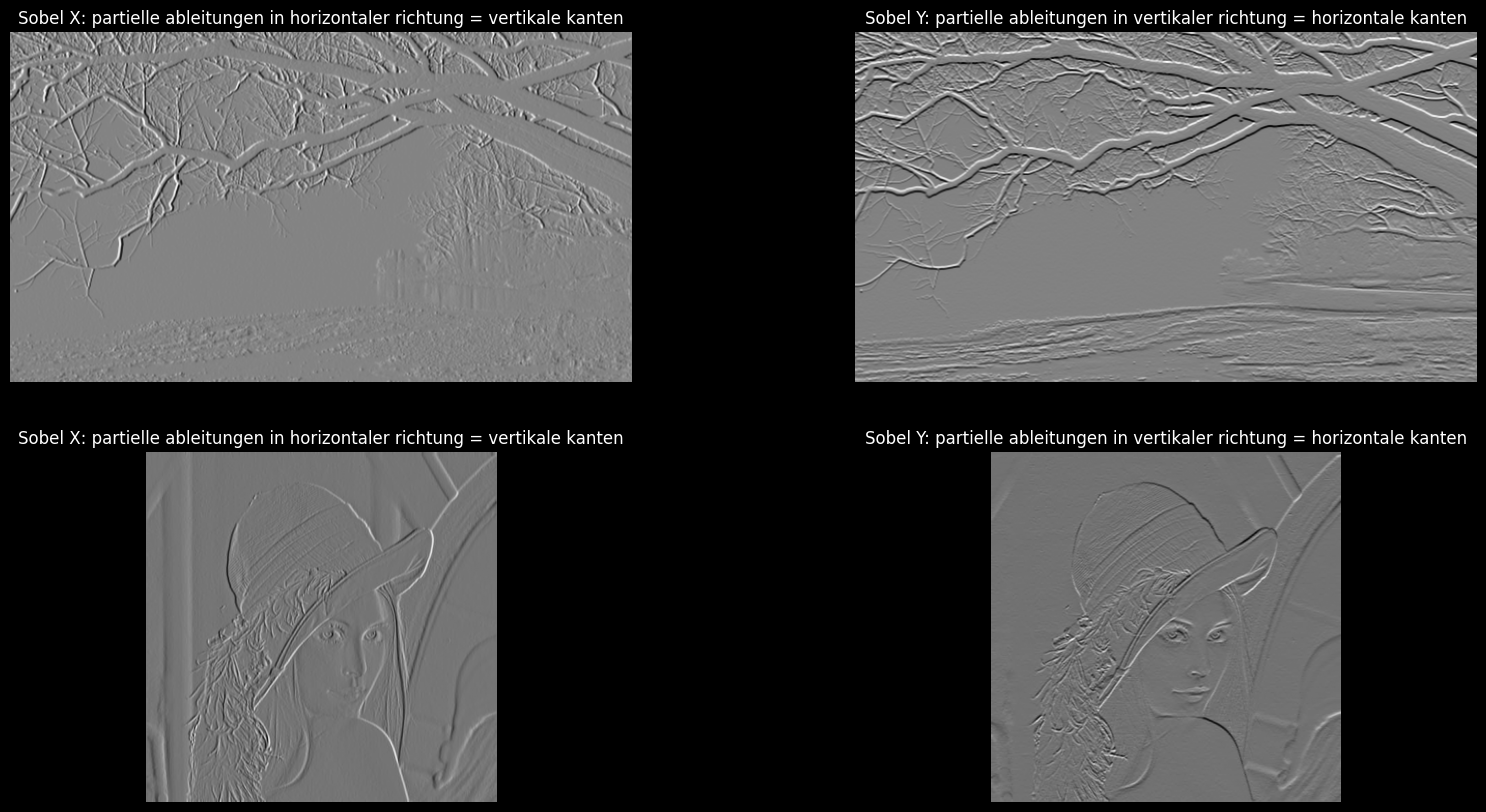

In [27]:
img_1_sobel_X = filter_2(image_1, sobel_x, edge='continue') * (1/8)
img_1_sobel_Y = filter_2(image_1, sobel_y, edge='continue') * (1/8)

img_2_sobel_X = filter_2(image_2, sobel_x, edge='continue') * (1/8)
img_2_sobel_Y = filter_2(image_2, sobel_y, edge='continue') * (1/8)

fig, axis = plt.subplots(2,2, figsize=(20, 10))
axis[0][0].imshow(img_1_sobel_X, cmap='gray')
axis[0][0].axis('off')
axis[0][0].set_title('Sobel X: partielle ableitungen in horizontaler richtung = vertikale kanten')

axis[0][1].imshow(img_1_sobel_Y, cmap='gray')
axis[0][1].axis('off')
axis[0][1].set_title('Sobel Y: partielle ableitungen in vertikaler richtung = horizontale kanten')

axis[1][0].imshow(img_2_sobel_X, cmap='gray')
axis[1][0].axis('off')
axis[1][0].set_title('Sobel X: partielle ableitungen in horizontaler richtung = vertikale kanten')

axis[1][1].imshow(img_2_sobel_Y, cmap='gray')
axis[1][1].axis('off')
axis[1][1].set_title('Sobel Y: partielle ableitungen in vertikaler richtung = horizontale kanten')

jetzt in separierter form

**Hx (vertikale Kanten):**
smooth vertikal  →  dann  diff horizontal

[1]                        [-1, 0, 1]

[2]

[1]

**Hy (horizontale Kanten):**

smooth horizontal  →  dann  diff vertikal

[1, 2, 1]                        [-1]

         [ 0]

         [ 1]

In [28]:
smooth = np.array([[1,2,1]])
diff = np.array([[-1,0,1]])

def ableitung_x(image, edge='continue'):
    tmp = filter_2(image, smooth.T, edge=edge)
    dx = filter_2(tmp, diff, edge=edge)
    return dx/8.0

def ableitung_y(image, edge='continue'):
    tmp = filter_2(image, smooth, edge=edge)
    dy = filter_2(tmp, diff.T, edge=edge)
    return dy/8.0

In [29]:
img_1_dx = ableitung_x(image_1)
img_1_dy = ableitung_y(image_1)

img_2_dx = ableitung_x(image_2)
img_2_dy = ableitung_y(image_2)

img_dot_01_dx = ableitung_x(img_dot_01)
img_dot_01_dy = ableitung_y(img_dot_01)

img_dot_02_dx = ableitung_x(img_dot_02)
img_dot_02_dy = ableitung_y(img_dot_02)

(np.float64(-0.5), np.float64(199.5), np.float64(199.5), np.float64(-0.5))

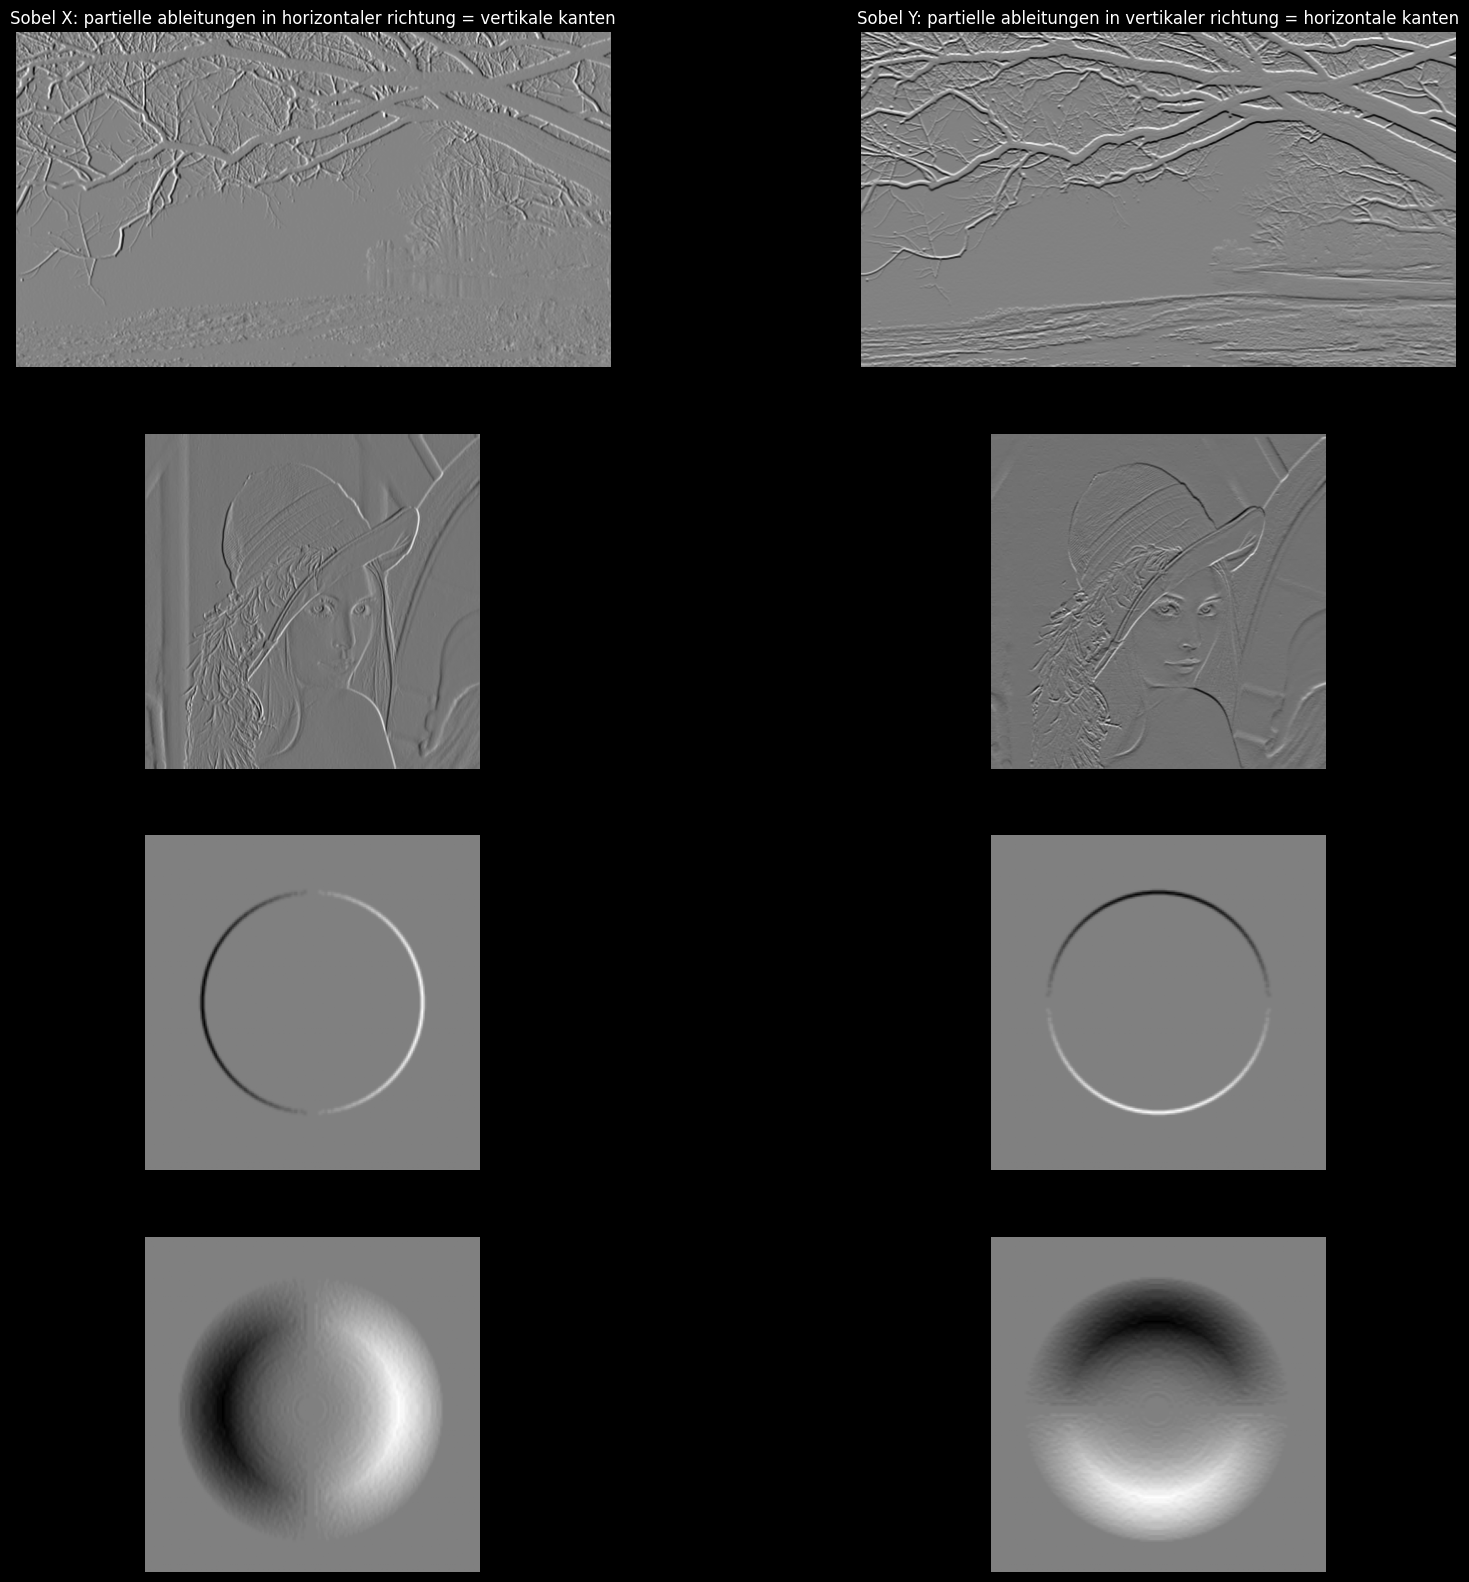

In [30]:
fig, axis = plt.subplots(4,2, figsize=(20, 20))
axis[0][0].imshow(img_1_dx, cmap='gray')
axis[0][0].axis('off')
axis[0][0].set_title('Sobel X: partielle ableitungen in horizontaler richtung = vertikale kanten')

axis[0][1].imshow(img_1_dy, cmap='gray')
axis[0][1].axis('off')
axis[0][1].set_title('Sobel Y: partielle ableitungen in vertikaler richtung = horizontale kanten')

axis[1][0].imshow(img_2_dx, cmap='gray')
axis[1][0].axis('off')

axis[1][1].imshow(img_2_dy, cmap='gray')
axis[1][1].axis('off')

axis[2][0].imshow(img_dot_01_dx, cmap='gray')
axis[2][0].axis('off')

axis[2][1].imshow(img_dot_01_dy, cmap='gray')
axis[2][1].axis('off')

axis[3][0].imshow(img_dot_02_dx, cmap='gray')
axis[3][0].axis('off')

axis[3][1].imshow(img_dot_02_dy, cmap='gray')
axis[3][1].axis('off')

d) Zusätzlich soll eine Funktion implementiert werden, die die Kantenstärke durch den
Betrag des Gradienten berechnet.

![image.png](attachment:fcb8a956-ae91-4b55-8417-805c64def12d.png)

In [31]:
def edge_strength(dx, dy):
    return np.sqrt(dx**2 + dy**2)

def edge_strength_img(image):
    dx = ableitung_x(image, edge='continue')
    dy = ableitung_y(image, edge='continue')
    return edge_strength(dx, dy)

In [32]:
img_1_edge_strength = edge_strength_img(image_1)
img_2_edge_strength = edge_strength_img(image_2)
img_dot_01_strength = edge_strength_img(img_dot_01)
img_dot_02_strength = edge_strength_img(img_dot_02)

(np.float64(-0.5), np.float64(199.5), np.float64(199.5), np.float64(-0.5))

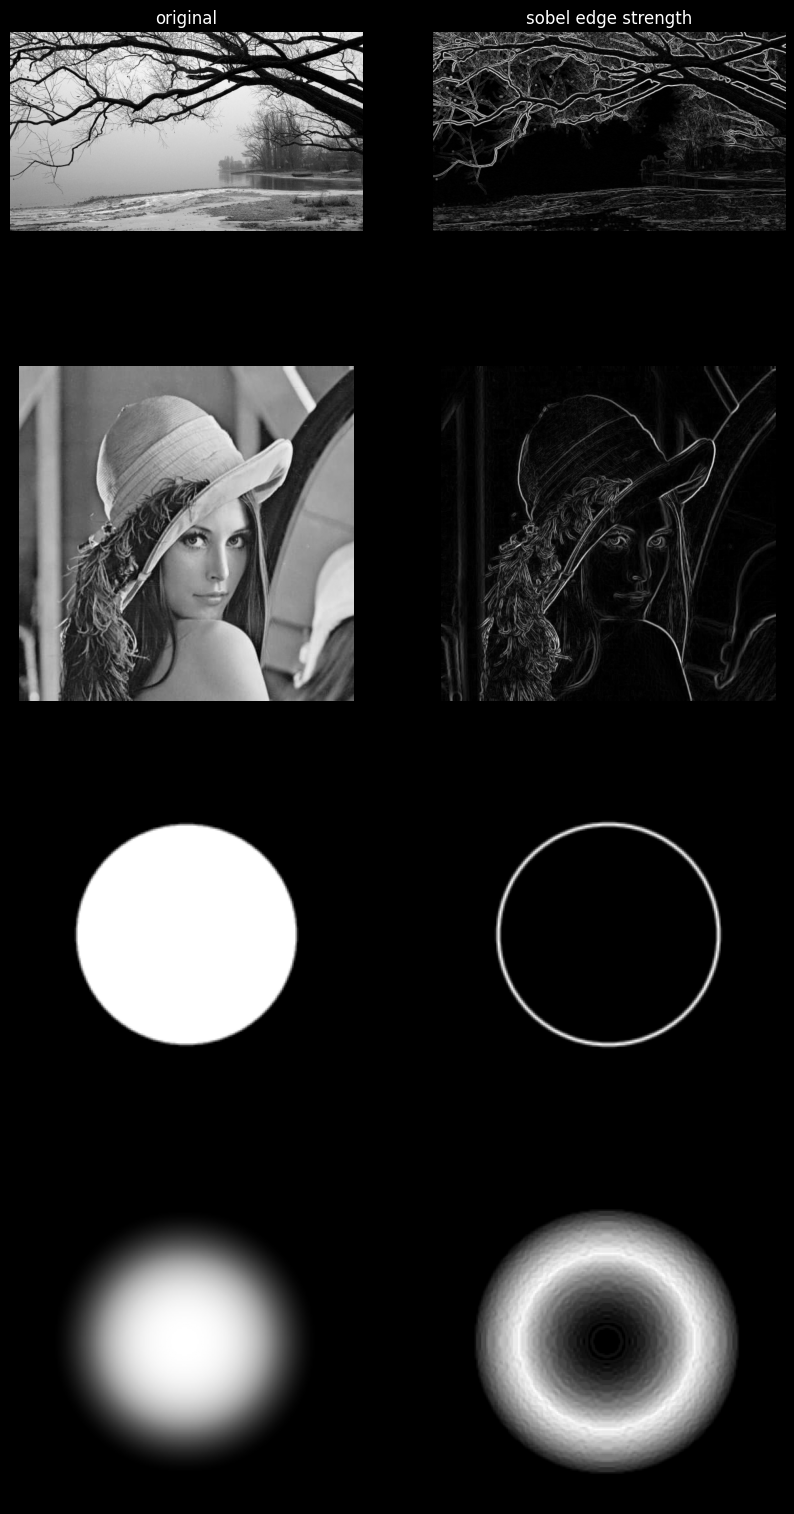

In [37]:
fig, axis = plt.subplots(4,2, figsize=(10, 20))

axis[0][0].imshow(image_1, cmap='gray')
axis[0][0].axis('off')
axis[0][0].set_title('original')

axis[0][1].imshow(img_1_edge_strength, cmap='gray')
axis[0][1].axis('off')
axis[0][1].set_title('sobel edge strength')

axis[1][0].imshow(image_2, cmap='gray')
axis[1][0].axis('off')

axis[1][1].imshow(img_2_edge_strength, cmap='gray')
axis[1][1].axis('off')

axis[2][0].imshow(img_dot_01, cmap='gray')
axis[2][0].axis('off')

axis[2][1].imshow(img_dot_01_strength, cmap='gray')
axis[2][1].axis('off')

axis[3][0].imshow(img_dot_02, cmap='gray')
axis[3][0].axis('off')

axis[3][1].imshow(img_dot_02_strength, cmap='gray')
axis[3][1].axis('off')

4. Beantworten Sie folgende Fragen:

a) Was sind die Nachteile des Sobel-Operators?
- hat nur eine 3x3 filterregion **->** kann also auch nur innerhalb der filtermatrix erfassen und somit keine größeren strukturen erkennen
- reale kante ist keine perfekte linie **->** kante ist so breit wie der intensitätsanstieg **->** ableitung reagiert auf den ganzen übergangsbereich **->** liefert also keine einzelne pixellinie als kante sondern einen dicken streifen **=>** je sanfter der übergang, desto breiter der streifen und dadurch kann man die kante nicht genau lokalisieren
- (sehr rauschempfindlich, deshalb kann man die 2. ableitung nicht einfach zur genauen lokalisierung verwenden) siehe letztes bild

b) Welche Alternativen gibt es zur Kantendetektion?
- roberts operator (2x2) filter entlang der diagonalen (regiert auf breites band an orientierungen ähnlich stark, also schlecht für richtungsschätzung)
- kirsch operator, löst das richtungs-problem durch 8 filter für 8 richtungen (0, 45, 90, 135 grad etc) -> kantenrichtung wird durch den am stärksten reagierenden filter bestimmt, aber laut buch kaum besser als sobel
- log (laplacian of gaussian) löst das besprochene lokalisierungsproblem von sobel durch eine gauss glättung, somit lassen sich die kanten aus der 2. ableitung ablesen
- canny filter (laut buch die beste lösung) 3 ziele gleichzeitig: wenige fehlmarkierungen -> keine falschen kanten, gute lokalisierung, nur eine markierung pro kante -> keine doppelten dicken kanten => verwendet gaussglättung, gradientenverfahren, nulldruchgönge der zweiten ableitung